# Inferencia con Pixtral 12B — Entrada: imagen + texto

## Importar librerías

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import json
import os
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

from transformers import LlavaForConditionalGeneration, AutoProcessor
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_curve,
    auc
)

from pyevall.evaluation import PyEvALLEvaluation
from pyevall.metrics.metricfactory import MetricFactory

## Configuración y parámetros

In [2]:
os.environ["HF_TOKEN"] = ""

MODEL_NAME = "mistral-community/pixtral-12b"
MAIN_PATH  = ".."
GROUP_ID   = "BeingChillingWeWillWin"
MODEL_ID   = "pixtral_12b"

TEXT_COLUMN  = "combined_text"
LABEL_COLUMN = "label"

DATA_TRAIN_PATH = os.path.join(MAIN_PATH, "preprocessed_data", "train_split.json")
DATA_VAL_PATH   = os.path.join(MAIN_PATH, "preprocessed_data", "dev_split.json")
DATA_TEST_PATH  = os.path.join(MAIN_PATH, "preprocessed_data", "test_split.json")

DATA_BASE_DIR   = os.path.join(MAIN_PATH, "materials", "dataset_task2_exist2026")
PREDICTIONS_DIR = os.path.join(MAIN_PATH, "predictions")
os.makedirs(PREDICTIONS_DIR, exist_ok=True)

MAX_NEW_TOKENS = 512
TEMPERATURE    = 0.3
TOP_P          = 0.9

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

label_map         = {"NO": 0, "YES": 1}
label_map_inverse = {0: "NO", 1: "YES"}

## Carga y preprocesamiento de datos

In [3]:
def load_json_dataset(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return pd.DataFrame(data.values())

def build_combined_text(row):
    img_desc = str(row.get('image_description', '') or '')
    txt      = str(row.get('text', '') or '')
    return f"descripcion imagen: {img_desc}. Texto: {txt}"

train_df = load_json_dataset(DATA_TRAIN_PATH)
val_df   = load_json_dataset(DATA_VAL_PATH)
test_df  = load_json_dataset(DATA_TEST_PATH)

for df in [train_df, val_df, test_df]:
    df[TEXT_COLUMN] = df.apply(build_combined_text, axis=1)

train_df["label_int"] = train_df[LABEL_COLUMN].map(label_map)
val_df["label_int"]   = val_df[LABEL_COLUMN].map(label_map)
test_df["label_int"]  = -1

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")
print(f"\nEjemplo de entrada:\n  {train_df[TEXT_COLUMN].iloc[0][:200]}")
print(f"\nDistribución de etiquetas en TRAIN:")
print(train_df[LABEL_COLUMN].value_counts())
print(f"\nDistribución de etiquetas en VAL:")
print(val_df[LABEL_COLUMN].value_counts())

Train size: 2146 | Val size: 537 | Test size: 687

Ejemplo de entrada:
  descripcion imagen: a close up of a snake with its mouth open and its tongue out. Texto: Demostración de que las cosas mas peligrosas del mundo tienen el mismo aspecto. mémenoides 

Distribución de etiquetas en TRAIN:
label
YES    1282
NO      864
Name: count, dtype: int64

Distribución de etiquetas en VAL:
label
YES    321
NO     216
Name: count, dtype: int64


## Carga del modelo Pixtral 12B

In [4]:
model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=DTYPE,
    device_map="auto"
).eval()

processor = AutoProcessor.from_pretrained(MODEL_NAME)

print(f"Modelo Pixtral 12B cargado en {DEVICE}")

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/585 [00:00<?, ?it/s]

chat_template.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

The image processor of type `PixtralImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

Modelo Pixtral 12B cargado en cuda


## Funciones de inferencia

In [5]:
def build_classification_prompt(combined_text):
    system_instruction = (
        "You are an expert content moderator specialized in identifying sexist content in memes. "
        "Your task is to analyze both the visual content and the text to determine if the meme "
        "contains sexist elements (stereotypes, discrimination, objectification, or derogatory content "
        "towards any gender).\n\n"
    )
    user_message = (
        f"Analyze this meme carefully. {combined_text}\n\n"
        "Does this meme contain sexist content?\n\n"
        "Answer ONLY with 'YES' if it contains sexist content, or 'NO' if it doesn't.\n"
        "Format: CLASSIFICATION: [YES/NO]"
    )
    return system_instruction + user_message


def parse_model_response(response_text):
    response_upper = response_text.upper()
    
    if "CLASSIFICATION: YES" in response_upper or "CLASSIFICATION:YES" in response_upper:
        classification = "YES"
    elif "CLASSIFICATION: NO" in response_upper or "CLASSIFICATION:NO" in response_upper:
        classification = "NO"
    elif response_upper.strip().startswith("YES"):
        classification = "YES"
    elif response_upper.strip().startswith("NO"):
        classification = "NO"
    else:
        classification = "NO"
        print(f"[WARN] No se pudo parsear: {response_text[:100]}")
    
    confidence = 0.9 if ("CLASSIFICATION:" in response_text) else 0.6
    return classification, confidence


@torch.no_grad()
def classify_image(image_path, combined_text, model, processor):
    try:
        image = Image.open(image_path).convert('RGB')
        prompt = f"[INST]{build_classification_prompt(combined_text)}[/INST]"
        
        inputs = processor(text=prompt, images=image, return_tensors="pt").to(model.device)
        
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
            top_p=TOP_P,
            do_sample=TEMPERATURE > 0
        )
        
        response = processor.decode(outputs[0], skip_special_tokens=True)
        response = response.split("[/INST]")[-1].strip() if "[/INST]" in response else response
        
        classification, confidence = parse_model_response(response)
        return {'classification': classification, 'confidence': confidence, 'raw_response': response}
        
    except Exception as e:
        print(f"[ERROR] {image_path}: {e}")
        return {'classification': 'NO', 'confidence': 0.0, 'raw_response': ''}


def process_dataset(df, base_dir, model, processor, split_name="dev"):
    results = []
    base_path = Path(base_dir)
    
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Inferencia {split_name}"):
        img_path = base_path / row['path_memes']
        prediction = classify_image(img_path, row[TEXT_COLUMN], model, processor)
        
        result = {
            'id_EXIST': str(row['id_EXIST']),
            'classification': prediction['classification'],
            'confidence': prediction['confidence'],
        }
        
        if 'label_int' in row.index and row['label_int'] >= 0:
            result['true_label'] = label_map_inverse[row['label_int']]
        
        results.append(result)
    
    return results


def save_probs_json(ids, probs, split_name, labels=None):
    records = []
    for i, (id_exist, prob) in enumerate(zip(ids, probs)):
        rec = {'id': str(id_exist), 'prob_YES': round(float(prob), 6)}
        if labels is not None:
            rec['label'] = label_map_inverse[int(labels[i])]
        records.append(rec)
    path = os.path.join(PREDICTIONS_DIR, f'{GROUP_ID}_{MODEL_ID}_probs_{split_name}.json')
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(records, f, ensure_ascii=False, indent=2)

## Inferencia en DEV y evaluación

Inferencia dev:   0%|          | 0/537 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[ERROR] ../materials/dataset_task2_exist2026/memes/111904.jpeg: Image features and image tokens do not match, tokens: 0, features: 3200000
[ERROR] ../materials/dataset_task2_exist2026/memes/210576.jpeg: Image features and image tokens do not match, tokens: 0, features: 6635520


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


...

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[ERROR] ../materials/dataset_task2_exist2026/memes/210046.jpeg: Image features and image tokens do not match, tokens: 0, features: 15728640
[ERROR] ../materials/dataset_task2_exist2026/memes/211278.jpeg: Image features and image tokens do not match, tokens: 0, features: 18677760


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[ERROR] ../materials/dataset_task2_exist2026/memes/210694.jpeg: Image features and image tokens do not match, tokens: 0, features: 5570560
[ERROR] ../materials/dataset_task2_exist2026/memes/211455.jpeg: Image features and image tokens do not match, tokens: 0, features: 5242880

Métricas en DEV:
  Accuracy : 0.4022
  Precision: 0.0000
  Recall   : 0.0000
  F1-Score : 0.0000

AUC (DEV): 0.5000


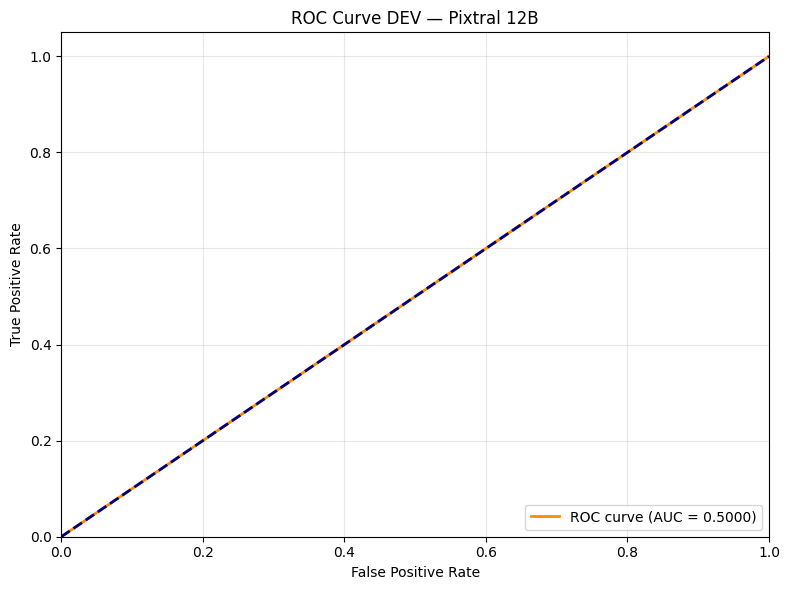

In [6]:
val_results = process_dataset(val_df, DATA_BASE_DIR, model, processor, split_name="dev")

y_pred_labels = [label_map[r['classification']] for r in val_results]
y_true_labels = [label_map[r['true_label']] for r in val_results]
y_probs_dev   = [r['confidence'] if r['classification'] == 'YES' else (1 - r['confidence']) for r in val_results]

accuracy = accuracy_score(y_true_labels, y_pred_labels)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true_labels, y_pred_labels, average='binary', zero_division=0
)

save_probs_json(val_df['id_EXIST'].values, y_probs_dev, 'dev', labels=val_df['label_int'].values)

print(f"\nMétricas en DEV:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

fpr, tpr, _ = roc_curve(y_true_labels, y_probs_dev)
roc_auc = auc(fpr, tpr)
print(f"\nAUC (DEV): {roc_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve DEV — Pixtral 12B')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluación en DEV con PyEvALL

In [7]:
dev_preds_for_pyevall = [
    {'test_case': 'EXIST2025', 'id': str(r['id_EXIST']), 'value': r['classification']}
    for r in val_results
]
dev_preds_df   = pd.DataFrame(dev_preds_for_pyevall)
dev_preds_path = os.path.join(PREDICTIONS_DIR, 'dev_predictions_temp.json')
with open(dev_preds_path, 'w', encoding='utf-8') as f:
    f.write(dev_preds_df.to_json(orient='records'))

dev_gold = [
    {'test_case': 'EXIST2025', 'id': str(id_exist), 'value': label}
    for id_exist, label in zip(val_df['id_EXIST'].values, val_df[LABEL_COLUMN].values)
]
dev_gold_df   = pd.DataFrame(dev_gold)
dev_gold_path = os.path.join(PREDICTIONS_DIR, 'dev_gold_temp.json')
with open(dev_gold_path, 'w', encoding='utf-8') as f:
    f.write(dev_gold_df.to_json(orient='records'))

test_eval = PyEvALLEvaluation()
metrics   = [MetricFactory.Accuracy.value, MetricFactory.FMeasure.value]
report    = test_eval.evaluate(dev_preds_path, dev_gold_path, metrics)
print("\n=== Evaluación en DEV con PyEvALL ===")
report.print_report()

2026-03-05 17:45:56,069 - pyevall.evaluation - INFO -             evaluate() - Evaluating the following metrics ['Accuracy', 'FMeasure']


2026-03-05 17:45:56,100 - pyevall.metrics.metrics - INFO -             evaluate() - Executing accuracy evaluation method


2026-03-05 17:45:56,162 - pyevall.metrics.metrics - INFO -             evaluate() - Executing fmeasure evaluation method



=== Evaluación en DEV con PyEvALL ===
{
  "metrics": {
    "Accuracy": {
      "name": "Accuracy",
      "acronym": "Acc",
      "description": "Coming soon!",
      "status": "OK",
      "results": {
        "test_cases": [{
          "name": "EXIST2025",
          "average": 0.4022346368715084
        }],
        "average_per_test_case": 0.4022346368715084
      }
    },
    "FMeasure": {
      "name": "F-Measure",
      "acronym": "F1",
      "description": "Coming soon!",
      "status": "OK",
      "results": {
        "test_cases": [{
          "name": "EXIST2025",
          "classes": {
            "YES": 0,
            "NO": 0.5737051792828686
          },
          "average": 0.2868525896414343
        }],
        "average_per_test_case": 0.2868525896414343
      }
    }
  },
  "files": {
    "dev_predictions_temp.json": {
      "name": "dev_predictions_temp.json",
      "status": "OK",
      "gold": false,
      "description": "Use parameter: report=\"embedded\"!",
      "er

## Inferencia en TEST y generación de predicciones finales

In [8]:
test_results = process_dataset(test_df, DATA_BASE_DIR, model, processor, split_name="test")

y_probs_test = [r['confidence'] if r['classification'] == 'YES' else (1 - r['confidence']) for r in test_results]
test_preds   = [r['classification'] for r in test_results]

save_probs_json(test_df['id_EXIST'].values, y_probs_test, 'test')

print(f"\nPredicciones en TEST:")
print(f"  Total: {len(test_preds)}")
print(f"  YES  : {sum(1 for p in test_preds if p == 'YES')} ({100*sum(1 for p in test_preds if p == 'YES')/len(test_preds):.2f}%)")
print(f"  NO   : {sum(1 for p in test_preds if p == 'NO')} ({100*sum(1 for p in test_preds if p == 'NO')/len(test_preds):.2f}%)")

Inferencia test:   0%|          | 0/687 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[ERROR] ../materials/dataset_task2_exist2026/memes/110887.jpeg: Image features and image tokens do not match, tokens: 0, features: 4608000


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


...

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[ERROR] ../materials/dataset_task2_exist2026/memes/211973.jpeg: Image features and image tokens do not match, tokens: 0, features: 7767040
[ERROR] ../materials/dataset_task2_exist2026/memes/211550.png: Image features and image tokens do not match, tokens: 0, features: 8192000
[ERROR] ../materials/dataset_task2_exist2026/memes/210131.jpeg: Image features and image tokens do not match, tokens: 0, features: 8294400


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[ERROR] ../materials/dataset_task2_exist2026/memes/210680.jpeg: Image features and image tokens do not match, tokens: 0, features: 5222400

Predicciones en TEST:
  Total: 687
  YES  : 0 (0.00%)
  NO   : 687 (100.00%)


## Guardar predicciones en formato PyEvALL para TEST

In [9]:
test_preds_for_submission = [
    {'test_case': 'EXIST2025', 'id': str(r['id_EXIST']), 'value': r['classification']}
    for r in test_results
]
test_preds_df = pd.DataFrame(test_preds_for_submission)

output_filename = f"{GROUP_ID}_{MODEL_ID}.json"
output_path     = os.path.join(PREDICTIONS_DIR, output_filename)

with open(output_path, 'w', encoding='utf-8') as f:
    f.write(test_preds_df.to_json(orient='records'))

print(f"\nPredicciones guardadas en: {output_path}")


Predicciones guardadas en: ../predictions/BeingChillingWeWillWin_pixtral_12b.json
